In [1]:
import numpy as np
import script.bonds as bd
import script.model as sim
import script.utility as utl
import copy
import scipy.special as spe
from importlib import reload
import matplotlib.pyplot as plt

from scipy.special import binom


from scipy.integrate import quad


def getFig(figsize=(4, 3), xlab="", ylab=""):
    fig, ax = plt.subplots(figsize=(5,4), dpi=100)
    if xlab:
        ax.set_xlabel(xlab)
    if ylab:
        ax.set_ylabel(ylab)
    return ax
tB = 1e-10

In [2]:
kT = 4.14
x1 = 1.5
x2 = 2.0

def eta(ta, tb, f):
    return tb/(ta*np.exp(-f*(x1-x2)/kT)+tb)

def tau(ta, tb,f):
    return ta*np.exp(-f*x1/kT)*eta(ta, tb, f)

def rm(i, ta, tb, f):
    return i*(np.exp(f*x1/(i*kT))/ta + np.exp(f*x2/(i*kT))/tb)

def drm(i, ta, tb, f):
    return  i*(np.exp(f*x2/(i*kT))/tb)/rm(i, ta, tb, f)**2

def gm(i, n0, ton):
    return (n0-i)/ton


def lifetime_ana(n0, ta, tb, F, ton=0):
    if ton ==0:
        return sum([1/rm(i, ta, tb, F) for i in range(1, n0+1)])
    ave = 0
    for i in range(1, n0+1):
        ave += tau(ta, tb, F/i)/i
    
    #print("ave0=", ave)
    #print("gm(1)=", gm(1,n0, ton))
    #print("rm(1)=", rm(5, ta, tb, F))
    ave0 = ave
    for i in range(1, n0):
        for j in range(i+1, n0+1):
            num, denom = 1, 1
            if j-i>=j:
                num = 0
            for k in range(j-i, j):
                num = num*gm(k, n0, ton)
                flag=True
            for k in range(j-i, j+1):
                denom = denom*rm(k, ta, tb, F)
            #print(ave)
            ave += num/denom
    return ave


def lifetime_sens(n0, ta, tb, F, ton, dt=1.1):
    t1 = lifetime_ana(n0, ta, tb, F, ton)
    t2 =lifetime_ana(n0, ta, tb*1.1, F,ton)
    return (np.log(t2)-np.log(t1))/0.1

def lifetime_sens_ana(n0,ta,tb,F,ton):
    sens= 0
    for i in range(1, n0+1):
        sens += drm(i, ta, tb, F)
        
    for i in range(1, n0):
        for j in range(i+1, n0+1):
            num, denom = 1, 1
            if j-i>=j:
                num = 0
            for k in range(j-i, j):
                num = num*gm(k, n0, ton)
                flag=True
            
            for k in range(j-i, j+1):
                denom = denom*rm(k, ta, tb, F)
                
            dev = 0
            for k in range(j-i, j+1):
                dev += (1- eta(ta, tb, F/k))/k
            #print(ave)
            sens += num*dev/denom   
    
    return sens/lifetime_ana(n0, ta, tb, F, ton)

def lifetime_xi(n0, ta, tb, F, ton):
    return lifetime_sens(n0, ta, tb, F, ton)/lifetime_std_ana(n0, ta, tb, F, ton)

def lifetime_std_ana(n0, ta, tb, F, ton):
    if ton ==0:
        return np.sqrt(sum([1/rm(i, ta, tb, F)**2 for i in range(1, n0+1)])) / lifetime_ana(n0, ta, tb,F,ton=0)
    ### calculate product gm i, j
    phi = np.zeros((n0+1, n0+1))
    
    for i in range(1, n0+1):
        for j in range(i+1, n0+1):
            num, denom = 1, 1
            if i>= j:
                num =0
            for k in range(i, j):
                num =num*gm(k, n0, ton)
            for k in range(i, j+1):
                denom = denom*rm(k, ta, tb, F)
            phi[i, j] = num/denom
    
    ## find the mean lifetime list
    T_ave_list = np.zeros(n0+1)
    for n in range(1, n0+1):
        t_ave = 0
        for i in range(1, n+1):
            t_ave += 1.0/rm(i, ta, tb, F)
            
            for j in range(i+1, n0+1):
                t_ave += phi[i, j]
                
        T_ave_list[n] = t_ave
    #print(T_ave_list)
    #print("lifetime=", T_ave_list[n0])

    ### calculate the variance
    T_std = 0
    for i in range(1, n0+1):
        T_std += 2*T_ave_list[i]/rm(i, ta, tb, F)
        
        for j in range(i+1, n0+1):
            T_std +=2*T_ave_list[j]*phi[i,j]
    #print("std =", np.sqrt(T_std-T_ave_list[n0]**2)/T_ave_list[n0])
    return np.sqrt(T_std-T_ave_list[n0]**2)/T_ave_list[n0]

In [3]:
num_points = 101
N0 = 100
Ta = 10
Tb = 5

In [4]:
# flist0s = np.logspace(-4, 2, num_points)
# tau_list0s = [lifetime_ana(N0, Ta, Tb, fi * 100, ton=0.1) for fi in flist0s]
# tau_std_list0s = [lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=0.1) for fi in flist0s]

In [5]:
flist0 = np.logspace(-4, 2, num_points)
tau_list0 = [lifetime_ana(N0, Ta, Tb, fi * 100, ton=1) for fi in flist0]
tau_std_list0 = [lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=1) for fi in flist0]

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: overflow encountered in exp
  
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:94: RuntimeWarning: overflow encountered in double_scalars


In [6]:
flist1 = np.logspace(-4, 2, num_points)
tau_list1 = [lifetime_ana(N0, Ta, Tb, fi * 100, ton=10) for fi in flist1]
tau_std_list1 = [lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=10) for fi in flist1]

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: overflow encountered in exp
  
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:94: RuntimeWarning: overflow encountered in double_scalars


In [7]:
flist2 = np.logspace(-4, 2, num_points)
tau_list2 = [lifetime_ana(N0, Ta, Tb, fi * 100, ton=100) for fi in flist2]
tau_std_list2 = [lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=100) for fi in flist2]

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: overflow encountered in exp
  
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:94: RuntimeWarning: overflow encountered in double_scalars


/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


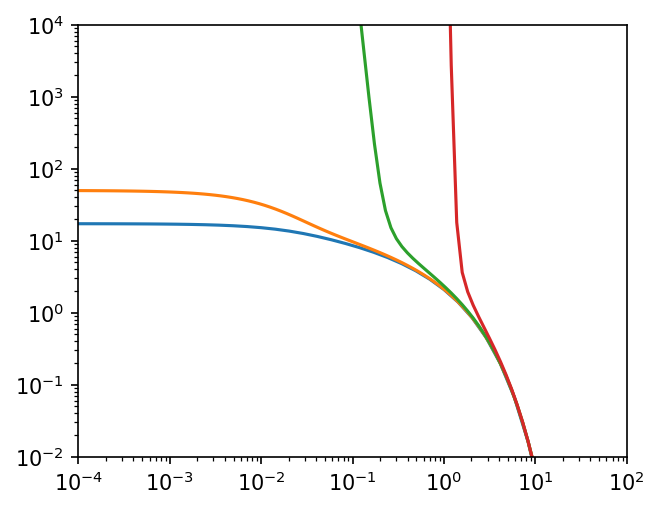

In [7]:

fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=150)
plt.plot(np.logspace(-4, 2, 40),[lifetime_ana(N0, Ta, Tb, fi * 100, ton=0) for fi in np.logspace(-4, 2, 40)])
plt.plot(flist2, tau_list2)
plt.plot(flist1, tau_list1)
plt.plot(flist0, tau_list0)

plt.xscale('log')
plt.xlim(1e-4, 1e2)
plt.ylim(1e-2, 1e4)
plt.yscale('log')
plt.tight_layout()
# plt.savefig("figs/Fig_S1_A.pdf", format='pdf', transparent=True)

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:82: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


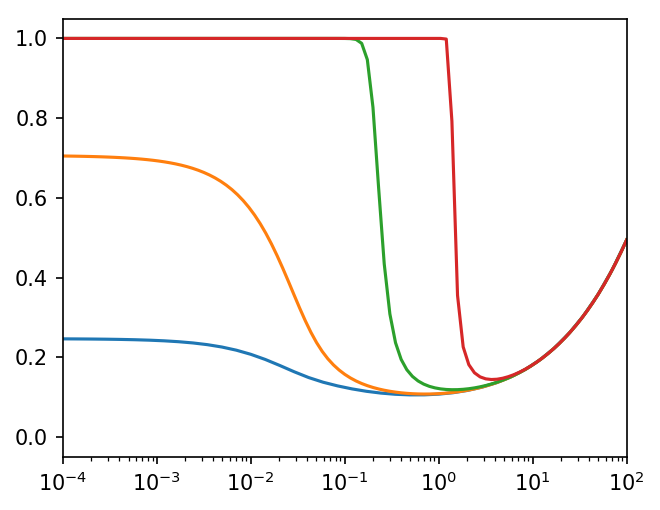

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=150)
plt.plot(np.logspace(-4, 2, 40),[lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=0) for fi in np.logspace(-4, 2, 40)])
plt.plot(flist2, tau_std_list2)
plt.plot(flist1, tau_std_list1)
plt.plot(flist0, tau_std_list0)

plt.xscale('log')
plt.xlim(1e-4, 1e2)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig("figs/Fig_S1_B.pdf", format='pdf', transparent=True)
plt.show()

In [9]:
def plot_tmean():
    
    fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=150)
    plt.plot(np.logspace(-4, 2, 40),[lifetime_ana(N0, Ta, Tb, fi * 100, ton=0) for fi in np.logspace(-4, 2, 40)])
    plt.plot(flist2, tau_list2)
    plt.plot(flist1, tau_list1)
    plt.plot(flist0, tau_list0)

    plt.xscale('log')
    plt.xlim(1e-4, 1e2)
    plt.ylim(1e-2, 1e4)
    plt.yscale('log')
    return ax

def plot_tstd():
    
    fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=150)
    plt.plot(np.logspace(-4, 2, 40),[lifetime_std_ana(N0, Ta, Tb, fi * 100, ton=0) for fi in np.logspace(-4, 2, 40)])
    plt.plot(flist2, tau_std_list2)
    plt.plot(flist1, tau_std_list1)
    plt.plot(flist0, tau_std_list0)

    plt.xscale('log')
    plt.xlim(1e-4, 1e2)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    return ax

## Stochastic simulations

In [18]:
import copy
import numpy as np
prm = copy.deepcopy(sim.prm_dict)
prm["f0"] = 5 * 100
prm["elist"] = [np.log(10), np.log(5), 0, 0]
prm["ton"] = 10e8


### Scan F

In [12]:
import json
def load_data(file_name):
    try:
        with open("data/figS1/"+file_name, "r") as fp:
            result = json.load(fp)
        print("loaded from file...")
    except:
        print("file not found: ", file_name)
        result =  {
            "f": [],
            "ton": [],
            "tmean": [],
            "tstd": [],
            "nag": [],
            "nstd": [],
        }
    return result

In [20]:


def scan_F(file_name, flist = np.logspace(2, -4, 11), ton=1e9, mode="a", num_run=1000):
    prm["ton"] = ton
    if mode == "w":
        result = {
            "f": [],
            "ton": [],
            "tmean": [],
            "tstd": [],
            "nag": [],
            "nstd": [],
        }
    else:
        result = load_data(file_name)
    print("flist: ", flist)
    for fi in flist:
        prm["f0"] = fi * 100
        sto = sim.Stoch(prm)
        sto.loadSharing=True
        sto.setup()
        sto.run(n=num_run)
        result["f"].append(fi)
        result["ton"].append(ton)
        result["tmean"].append(np.mean(sto.tlist))
        result["tstd"].append(np.std(sto.tlist))
        result["nag"].append(sto.nbar)
        result["nstd"].append(sto.nstd)
        print("f:",fi, "\ttmean:", np.mean(sto.tlist), "\tnag:", sto.nbar)
        with open("data/figS1/" + file_name , "w") as fp:
            json.dump(result, fp)
    print("saved to data/figS1/" + file_name)
    print("DONE!")
    return result
    
# result_ton10 = scan_F(
#     file_name="scan_F_ton1.json",
#     flist = np.logspace(2, 0, 11),
#     ton=1,
#     mode="w",
#     num_run=1000
# )

In [23]:
result_ton10 = scan_F(
    file_name="scan_F_ton1000_v2.json",
    flist = np.logspace(1, -4, 11),
    ton=1000,
    mode="w",
    num_run=5000
)

flist:  [100.          50.11872336  25.11886432  12.58925412   6.30957344
   3.16227766   1.58489319   0.79432823   0.39810717   0.19952623
   0.1       ]
count= 5000................................................99%
nbar=0.00000, nstd=0.00000, t=0.00, f=10000.000
f: 100.0 	tmean: 1.3503939317224095e-22 	nag: 0.0
count= 5000................................................99%
nbar=0.01640, nstd=0.12701, t=0.00, f=5011.872
f: 50.11872336272722 	tmean: 6.879345814289967e-12 	nag: 0.0164
count= 5000................................................99%
nbar=0.52200, nstd=0.72603, t=0.00, f=2511.886
f: 25.118864315095795 	tmean: 2.1546904545158856e-06 	nag: 0.522
count= 5000................................................99%
nbar=3.43000, nstd=1.79908, t=0.00, f=1258.925
f: 12.589254117941675 	tmean: 0.0015611937483946481 	nag: 3.43
count= 5000................................................99%
nbar=9.26080, nstd=2.82736, t=0.05, f=630.957
f: 6.309573444801933 	tmean: 0.05252124178607619 	nag

KeyboardInterrupt: 

In [47]:
result_ton1000 = scan_F(
    file_name="scan_F_kon0_v2.json",
    flist = np.logspace(1, -4, 11),
    ton=1e20,
    mode="w",
    num_run=5000
)

flist:  [1.00000000e+01 3.16227766e+00 1.00000000e+00 3.16227766e-01
 1.00000000e-01 3.16227766e-02 1.00000000e-02 3.16227766e-03
 1.00000000e-03 3.16227766e-04 1.00000000e-04]
count= 5000................................................99%
nbar=5.05280, nstd=2.18046, t=0.01, f=1000.000
f: 10.0 	tmean: 0.0064233659127867215 	nag: 5.0528
count= 5000................................................99%
nbar=16.03460, nstd=3.56525, t=0.38, f=316.228
f: 3.1622776601683795 	tmean: 0.37829020947362285 	nag: 16.0346
count= 5000................................................99%
nbar=25.07800, nstd=4.31299, t=2.11, f=100.000
f: 1.0 	tmean: 2.10966360402237 	nag: 25.078
count= 5000................................................99%
nbar=29.80100, nstd=4.52732, t=5.07, f=31.623
f: 0.31622776601683794 	tmean: 5.074388161280407 	nag: 29.801
count= 5000................................................99%
nbar=32.07380, nstd=4.72160, t=8.60, f=10.000
f: 0.1 	tmean: 8.59905482335075 	nag: 32.0738
count= 

In [13]:
result = load_data("scan_F_kon0_v2.json")
# result_ton1000 = load_data("scan_F_ton1000_v2.json")
result_ton100 = load_data("scan_F_ton100_v2.json")
result_ton10 = load_data("scan_F_ton10_v2.json")
result_ton1 = load_data("scan_F_ton1.json")

loaded from file...
loaded from file...
loaded from file...
loaded from file...


In [39]:
# result_ton10 = load_data("scan_F_ton10_v2.json")

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


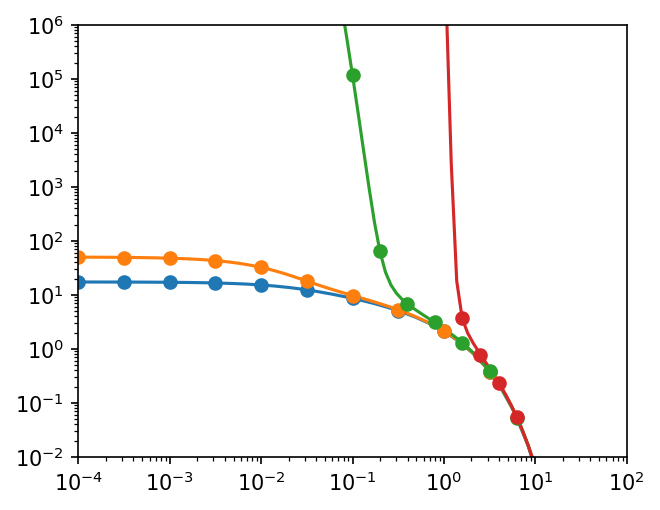

In [20]:
flist2 = np.logspace(-4, 2, num_points)
ax = plot_tmean()
for rs, cr in zip([result, result_ton100, result_ton10, result_ton1], ["C0", "C1", "C2", "C3"]):

    ax.plot(rs["f"], rs["tmean"], 'o', color=cr)
plt.ylim(1e-2, 1e6)
plt.tight_layout()
plt.savefig("figs/Fig_S1_A_symbol_v2.pdf", format='pdf', transparent=True)

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:82: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


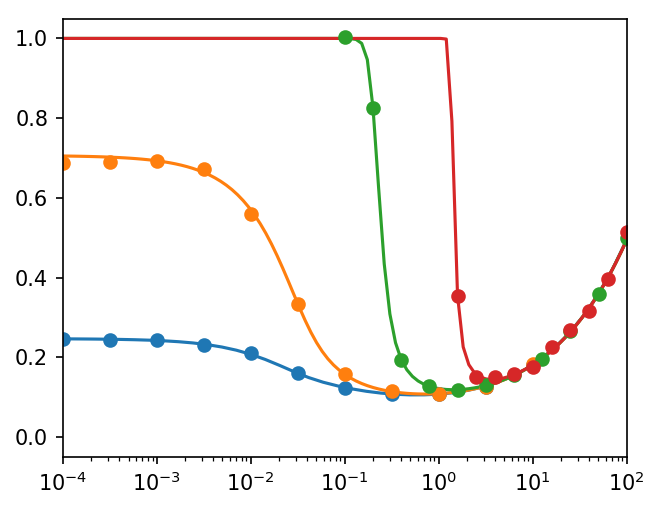

In [19]:
ax = plot_tstd()
for rs, cr in zip([result, result_ton100, result_ton10, result_ton1], ["C0", "C1", "C2", "C3"]):
    ax.plot(rs["f"], np.asarray(rs["tstd"])/np.asarray(rs["tmean"]), 'o', color=cr)
plt.tight_layout()
plt.savefig("figs/Fig_S1_B_symbol_v2.pdf", format='pdf', transparent=True)


In [23]:
for fi, nag in zip(result["f"], result["nag"]):
    print("{0:.4f}, {1:.2f}".format(fi, nag), end="}, {")

10.0000, 5.05}, {3.1623, 16.03}, {1.0000, 25.08}, {0.3162, 29.80}, {0.1000, 32.07}, {0.0316, 32.99}, {0.0100, 33.26}, {0.0032, 33.37}, {0.0010, 33.18}, {0.0003, 33.32}, {0.0001, 33.26}, {

In [24]:
for fi, nag in zip(result_ton100["f"], result_ton100["nag"]):
    print("{0:.4f}, {1:.2f}".format(fi, nag), end="}, {")

10.0000, 5.03}, {3.1623, 16.02}, {1.0000, 24.98}, {0.3162, 29.84}, {0.1000, 32.02}, {0.0316, 32.61}, {0.0100, 33.13}, {0.0032, 33.24}, {0.0010, 33.27}, {0.0003, 33.24}, {0.0001, 33.29}, {

In [25]:
for fi, nag in zip(result_ton10["f"], result_ton10["nag"]):
    print("{0:.4f}, {1:.2f}".format(fi, nag), end="}, {")

100.0000, 0.00}, {50.1187, 0.02}, {25.1189, 0.52}, {12.5893, 3.43}, {6.3096, 9.26}, {3.1623, 16.16}, {1.5849, 21.79}, {0.7943, 25.90}, {0.3981, 28.30}, {0.1995, 28.89}, {

In [26]:
for fi, nag in zip(result_ton1["f"], result_ton1["nag"]):
    print("{0:.4f}, {1:.2f}".format(fi, nag), end="}, {")

100.0000, 0.00}, {63.0957, 0.00}, {39.8107, 0.07}, {25.1189, 0.52}, {15.8489, 2.04}, {10.0000, 5.09}, {6.3096, 9.16}, {3.9811, 13.79}, {2.5119, 17.36}, {1.5849, 19.67}, {

## num_run = 5000

In [25]:
for fi, nag in zip(result_ton10_v2["f"], result_ton10_v2["nstd"]):
    print("{0:.4f}, {1:.2f}".format(fi, nag), end="}, {")

100.0000, 0.00}, {50.1187, 0.13}, {25.1189, 0.73}, {12.5893, 1.80}, {6.3096, 2.83}, {3.1623, 3.58}, {1.5849, 4.01}, {0.7943, 4.38}, {0.3981, 4.52}, {0.1995, 4.46}, {

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


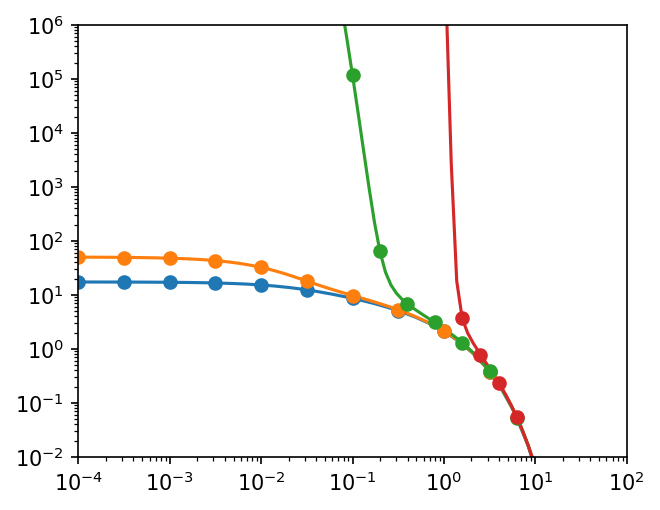

In [17]:
flist2 = np.logspace(-4, 2, num_points)
ax = plot_tmean()
for rs, cr in zip([result, result_ton100, result_ton10, result_ton1], ["C0", "C1", "C2", "C3"]):

    ax.plot(rs["f"], rs["tmean"], 'o', color=cr)
plt.ylim(1e-2, 1e6)
plt.tight_layout()
# plt.savefig("figs/Fig_S1_A_symbol.pdf", format='pdf', transparent=True)

/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:82: RuntimeWarning: overflow encountered in double_scalars
/Users/skyhd/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


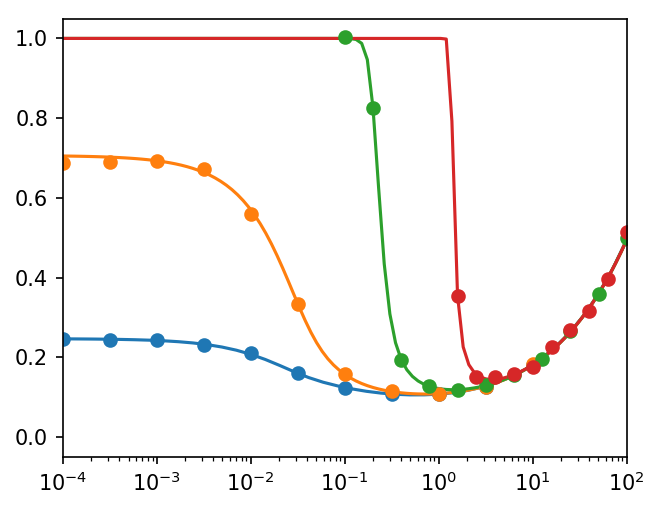

In [18]:
ax = plot_tstd()
for rs, cr in zip([result, result_ton100, result_ton10, result_ton1], ["C0", "C1", "C2", "C3"]):
    ax.plot(rs["f"], np.asarray(rs["tstd"])/np.asarray(rs["tmean"]), 'o', color=cr)
plt.tight_layout()